# EDA — PAMAP2 Physical Activity Monitoring Dataset
Análisis exploratorio previo al entrenamiento del modelo.
Identifica: distribución de clases, calidad de señal, leakage, drift, desbalance.

## 1. Carga de datos y configuración

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import yaml
from pathlib import Path
from scipy.signal import butter, filtfilt, welch

# Estilo global
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
COLORS = ["#1D9E75", "#534AB7", "#D85A30", "#BA7517", "#E24B4A"]

with open("../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

PROCESSED_H5 = Path(cfg["paths"]["processed"]) / "pamap2_features.h5"
RAW_DIR      = Path(cfg["paths"]["raw_public"])
FIGURES_DIR  = Path(cfg["paths"]["figures"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset procesado: {PROCESSED_H5}")
print(f"Directorio figuras: {FIGURES_DIR}")

Dataset procesado: data\processed\pamap2_features.h5
Directorio figuras: reports\figures


## 2. Carga del dataset procesado

In [3]:
import os
from pathlib import Path

# Asegura que el directorio de trabajo sea siempre la raíz del proyecto
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [4]:
with h5py.File(PROCESSED_H5, "r") as f:
    X           = f["X"][:]
    y           = f["y"][:]
    subject_ids = f["subject_ids"][:]
    meta        = dict(f.attrs)

print(f"\nShape X (ventanas × features): {X.shape}")
print(f"Shape y (etiquetas):            {y.shape}")
print(f"Sujetos únicos:                 {np.unique(subject_ids)}")
print(f"\nMetadatos del pipeline:")
for k, v in meta.items():
    print(f"  {k}: {v}")


Shape X (ventanas × features): (194205, 297)
Shape y (etiquetas):            (194205,)
Sujetos únicos:                 [1 2 3 4 5 6 7 8 9]

Metadatos del pipeline:
  created_at: 2026-05-01T19:59:30
  feature_names: ['rms', 'mav', 'wl', 'zc', 'ssc', 'var', 'mdf', 'mnf', 'band_low', 'band_mid', 'band_high']
  filter_highcut: 40.0
  filter_lowcut: 0.5
  label_map: {1: 0, 2: 0, 3: 0, 4: 0, 5: 1, 6: 1, 7: 1, 12: 1, 13: 1, 16: 2, 17: 2, 24: 2}
  n_features: 297
  n_subjects: 9
  n_windows: 194205
  overlap_ratio: 0.5
  sampling_rate_hz: 100
  seed: 42
  segments: ['hand', 'chest', 'ankle']
  window_ms: 200


## 3. Estadísticas descriptivas básicas

In [5]:
df_meta = pd.DataFrame({
    "subject": subject_ids,
    "risk_level": y,
})
df_meta["risk_label"] = df_meta["risk_level"].map({
    0: "Bajo riesgo",
    1: "Riesgo medio",
    2: "Riesgo alto",
})

# Tabla de distribución por sujeto y clase
pivot = df_meta.groupby(["subject", "risk_label"]).size().unstack(fill_value=0)
print("\nVentanas por sujeto y nivel de riesgo:")
print(pivot)
print(f"\nTotal ventanas: {len(y):,}")
print(f"Total features: {X.shape[1]}")

# Estadísticas de los features
df_X = pd.DataFrame(X)
desc = df_X.describe().T
print(f"\nEstadísticas de features (primeras 10 columnas):")
print(desc.head(10).round(3))


Ventanas por sujeto y nivel de riesgo:
risk_label  Bajo riesgo  Riesgo alto  Riesgo medio
subject                                           
1                  9461         5938          9586
2                 10386         6278          9659
3                 10033         4828          2565
4                 10514         4501          8118
5                 10469         6518         10246
6                  9642         5904          9453
7                  9733         5103          8432
8                 10375         6606          9219
9                     0          638             0

Total ventanas: 194,205
Total features: 297

Estadísticas de features (primeras 10 columnas):
      count   mean    std    min    25%    50%    75%     max
0  194205.0  2.381  3.156  0.021  0.226  1.572  3.151  44.339
1  194205.0  2.629  4.494  0.016  0.297  1.337  2.669  57.437
2  194205.0  1.478  1.716  0.030  0.258  1.069  1.943  32.647
3  194205.0  0.821  0.941  0.007  0.133  0.538  1.147  1

## 4. Distribución de clases — riesgo de desbalance

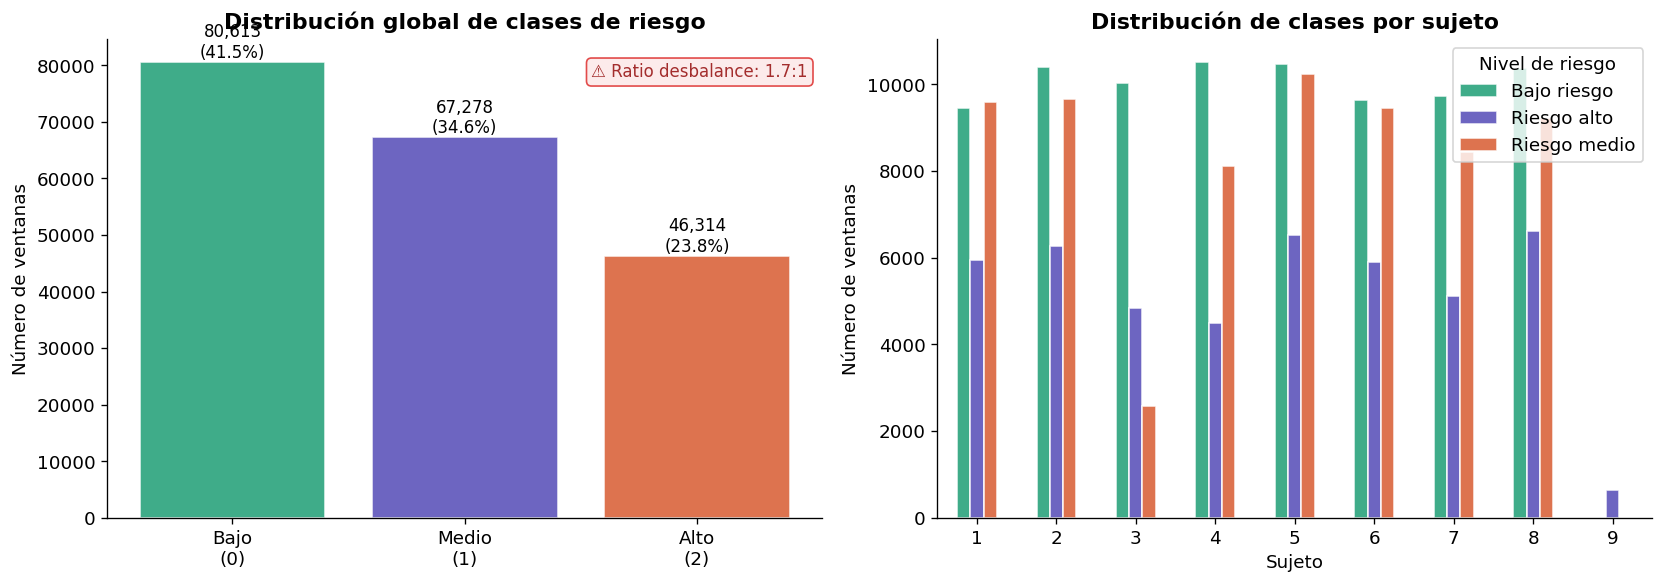

[Riesgo identificado] Ratio de desbalance: 1.7:1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Global
class_counts = pd.Series(y).value_counts().sort_index()
class_labels  = ["Bajo\n(0)", "Medio\n(1)", "Alto\n(2)"]
bars = axes[0].bar(class_labels, class_counts.values, color=COLORS[:3], alpha=0.85, edgecolor="white")
axes[0].set_title("Distribución global de clases de riesgo", fontweight="bold")
axes[0].set_ylabel("Número de ventanas")
for bar, count in zip(bars, class_counts.values):
    pct = count / len(y) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

# ── RIESGO: Desbalance ───────────────────────────────────────
imbalance_ratio = class_counts.max() / class_counts.min()
axes[0].text(0.98, 0.95, f"⚠ Ratio desbalance: {imbalance_ratio:.1f}:1",
             transform=axes[0].transAxes, ha="right", va="top",
             color="#A32D2D", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="#FCEBEB", ec="#E24B4A"))

# Por sujeto
pivot.plot(kind="bar", ax=axes[1], color=COLORS[:3], alpha=0.85, edgecolor="white")
axes[1].set_title("Distribución de clases por sujeto", fontweight="bold")
axes[1].set_xlabel("Sujeto")
axes[1].set_ylabel("Número de ventanas")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Nivel de riesgo", loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"[Riesgo identificado] Ratio de desbalance: {imbalance_ratio:.1f}:1")

## 5. Distribución de features clave — histogramas y boxplots

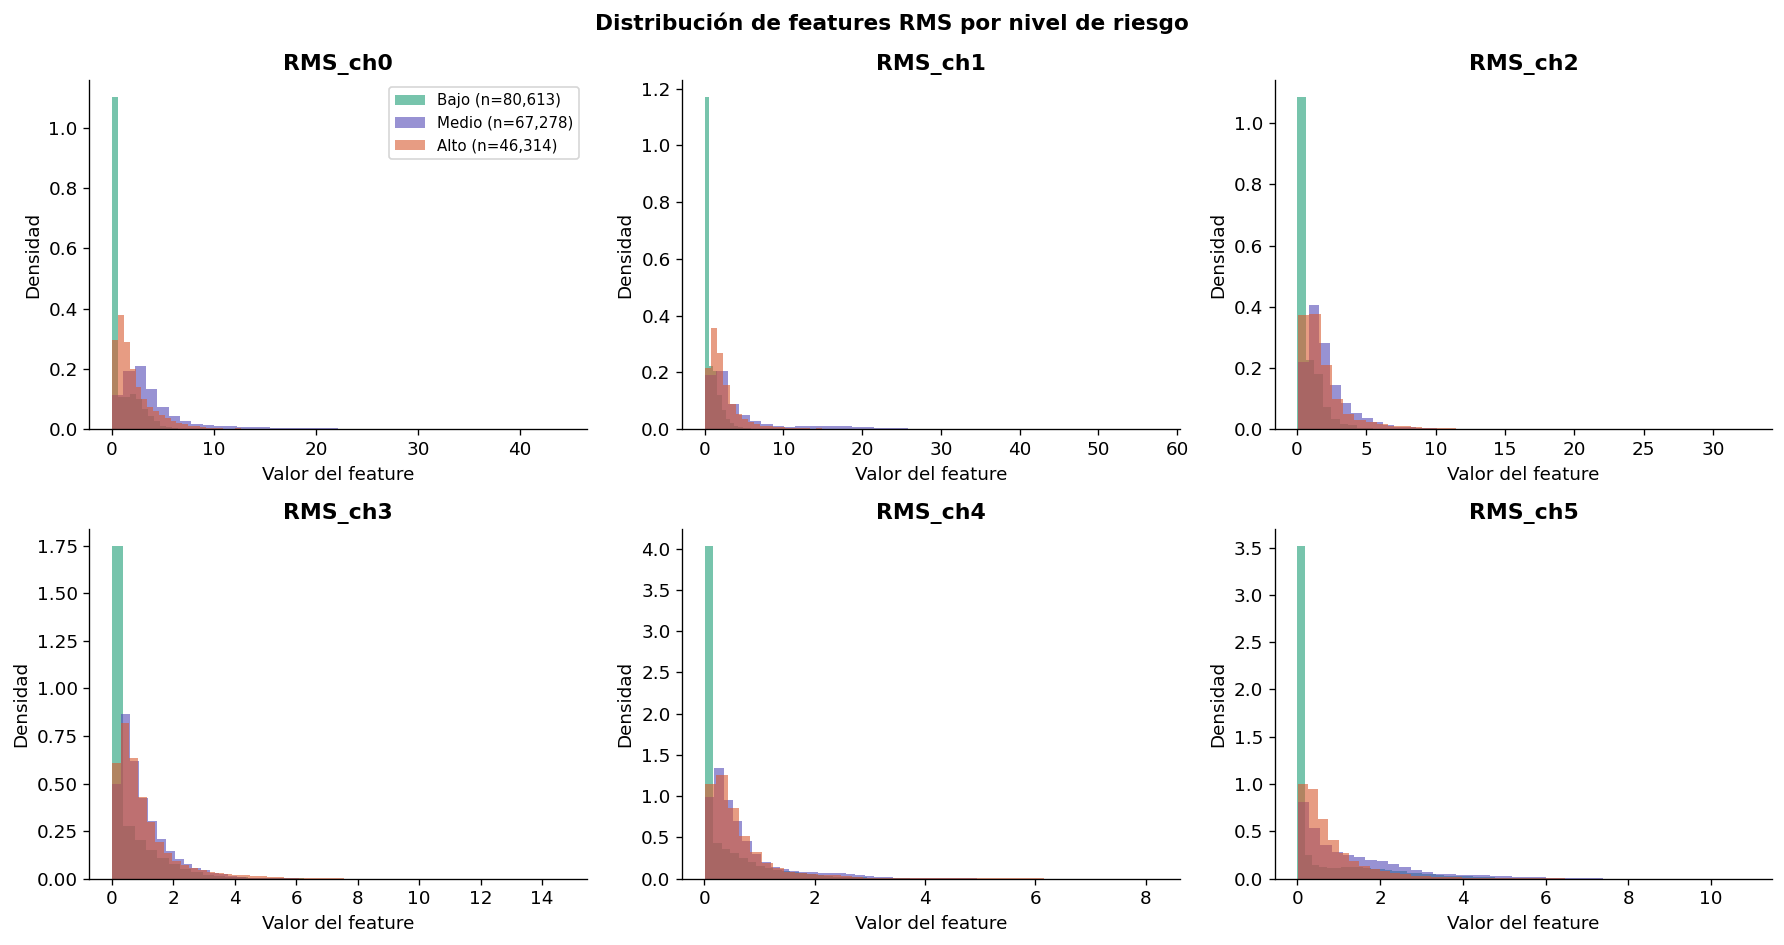

In [7]:
# Mostrar los primeros 6 features (RMS de cada canal)
n_features_show = 6
feature_names = [f"RMS_ch{i}" for i in range(n_features_show)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
risk_labels = {0: "Bajo", 1: "Medio", 2: "Alto"}
axes = axes.flatten()

for i in range(n_features_show):
    ax = axes[i]
    for level, color in zip([0, 1, 2], COLORS[:3]):
        mask = y == level
        values = X[mask, i]
        values = values[np.isfinite(values)]
        ax.hist(values, bins=40, alpha=0.6, color=color,
                label=f"{risk_labels[level]} (n={mask.sum():,})", density=True)
    ax.set_title(feature_names[i], fontweight="bold")
    ax.set_xlabel("Valor del feature")
    ax.set_ylabel("Densidad")
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle("Distribución de features RMS por nivel de riesgo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_feature_distributions.png", bbox_inches="tight")
plt.show()

## 6. Análisis de calidad de señal — NaN, Inf, outliers

In [8]:
print("=== ANÁLISIS DE CALIDAD DE DATOS ===\n")

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()
print(f"NaN en X:  {nan_count:,}")
print(f"Inf en X:  {inf_count:,}")

# Outliers por feature (z-score > 5)
from scipy import stats
z_scores  = np.abs(stats.zscore(X, nan_policy="omit"))
n_outliers = (z_scores > 5).sum()
pct_outliers = n_outliers / X.size * 100
print(f"Outliers (|z|>5): {n_outliers:,} ({pct_outliers:.2f}%)")

# Varianza cero (features constantes — señal de leakage o error)
zero_var_cols = np.where(np.var(X, axis=0) < 1e-10)[0]
print(f"Features con varianza ≈ 0: {len(zero_var_cols)}")
if len(zero_var_cols):
    print(f"  Columnas: {zero_var_cols}")
    print("  ⚠ RIESGO DE LEAKAGE — verificar si estas columnas contienen la etiqueta")

=== ANÁLISIS DE CALIDAD DE DATOS ===

NaN en X:  0
Inf en X:  0
Outliers (|z|>5): 144,822 (0.25%)
Features con varianza ≈ 0: 27
  Columnas: [216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242]
  ⚠ RIESGO DE LEAKAGE — verificar si estas columnas contienen la etiqueta


## 7. Riesgos identificados — Resumen formal

In [9]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           RIESGOS IDENTIFICADOS EN EDA                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DESBALANCE DE CLASES                                        ║
║  • Ratio máx/mín: ver gráfica anterior                       ║
║  • Mitigación: class_weight=balanced + F1-Macro como métrica ║
║                                                              ║
║  RIESGO DE LEAKAGE                                           ║
║  • PAMAP2 tiene 9 sujetos con características demográficas   ║
║    distintas. Si se usa split aleatorio en lugar de LOSO,    ║
║    ventanas del mismo sujeto en train y test inflan el Acc.  ║
║  • Mitigación: LOSO estricto (evaluación.strategy=loso)      ║
║                                                              ║
║  DOMAIN DRIFT (dominio fuente → objetivo)                    ║
║  • PAMAP2 = actividades cotidianas, no perforación minera    ║
║  • Diferencia de distribución estadística entre dominios     ║
║  • Mitigación: DANN (Entregable 7) — razón central de tesis  ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           RIESGOS IDENTIFICADOS EN EDA                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DESBALANCE DE CLASES                                        ║
║  • Ratio máx/mín: ver gráfica anterior                       ║
║  • Mitigación: class_weight=balanced + F1-Macro como métrica ║
║                                                              ║
║  RIESGO DE LEAKAGE                                           ║
║  • PAMAP2 tiene 9 sujetos con características demográficas   ║
║    distintas. Si se usa split aleatorio en lugar de LOSO,    ║
║    ventanas del mismo sujeto en train y test inflan el Acc.  ║
║  • Mitigación: LOSO estricto (evaluación.strategy=loso)      ║
║                                                              ║
║  DOMAIN DRIFT (dominio fuente → objetivo)                    ║
║  • PAMAP2 = actividades

## 8. Heatmap de correlación entre features

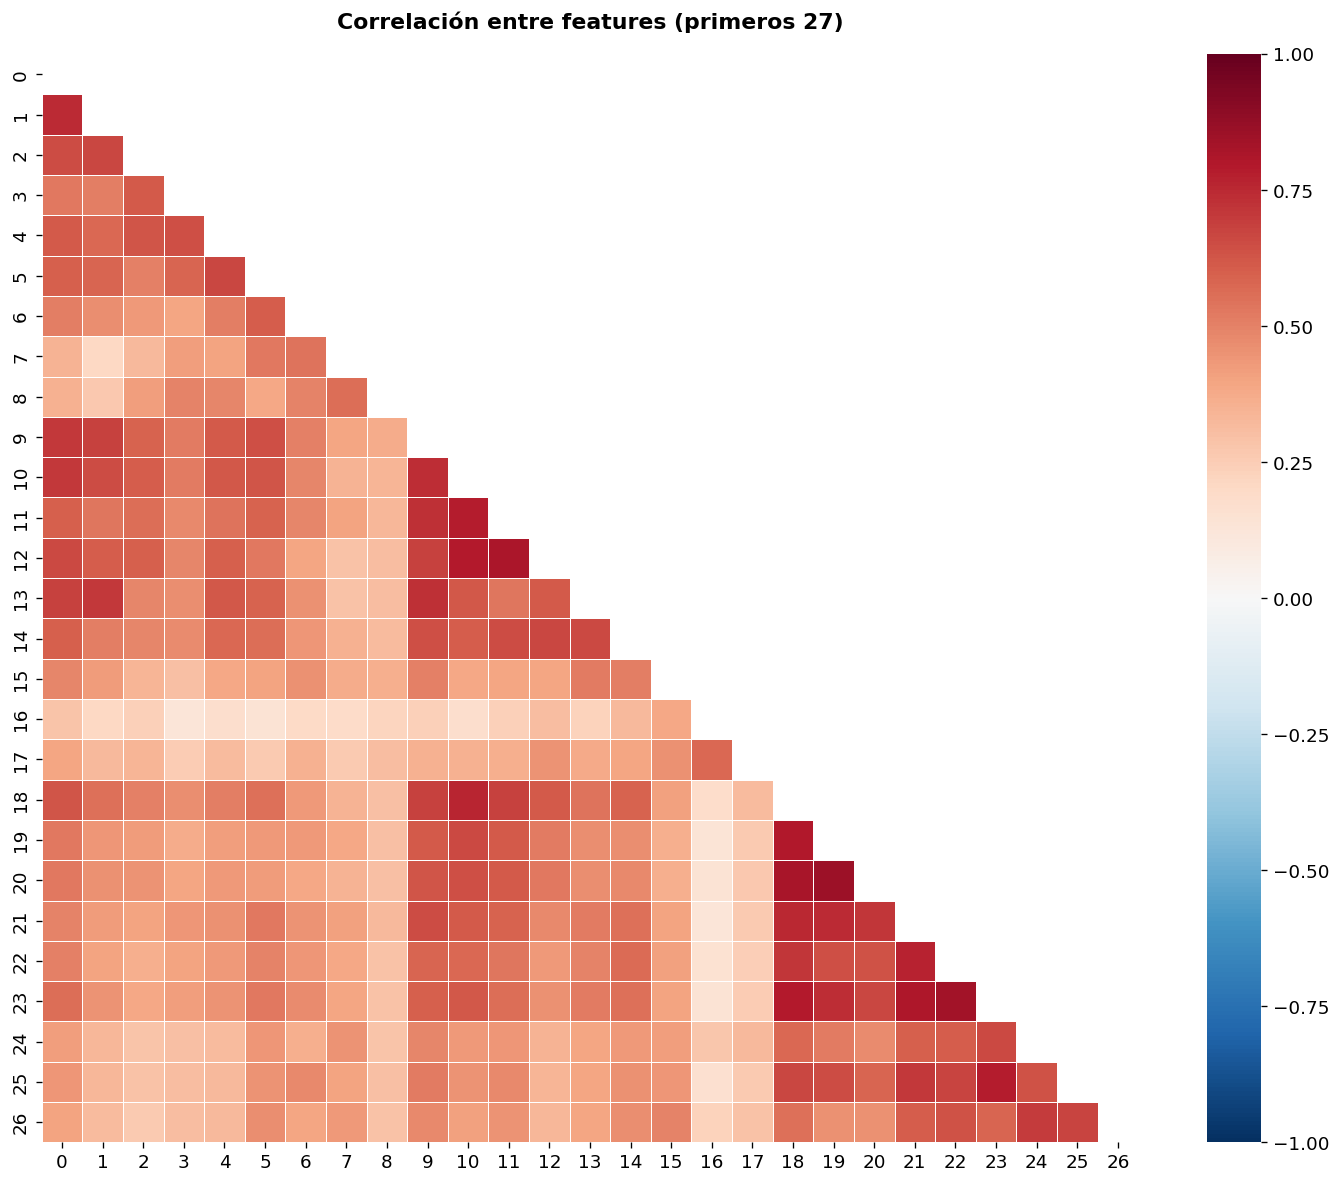

EDA completado. Figuras guardadas en: reports\figures


In [10]:
# Muestra la matriz de correlación de los primeros 27 features
n_show = 27
corr_matrix = pd.DataFrame(X[:, :n_show]).corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    center=0,
    annot=False,
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Correlación entre features (primeros 27)", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("EDA completado. Figuras guardadas en:", FIGURES_DIR)